In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
import pandas as pd
from skimage import io

%matplotlib widget

In [2]:
plt.close('all')

In [3]:
x = np.asarray([43.        , 42.87755102, 42.75510204, 42.63265306, 42.51020408,
        42.3877551 , 42.26530612, 42.14285714, 42.02040816, 41.89795918,
        41.7755102 , 41.65306122, 41.53061224, 41.40816327, 41.28571429,
        41.16326531, 41.04081633, 40.91836735, 40.79591837, 40.67346939,
        40.55102041, 40.42857143, 40.30612245, 40.18367347, 40.06122449,
        39.93877551, 39.81632653, 39.69387755, 39.57142857, 39.44897959,
        39.32653061, 39.20408163, 39.08163265, 38.95918367, 38.83673469,
        38.71428571, 38.59183673, 38.46938776, 38.34693878, 38.2244898 ,
        38.10204082, 37.97959184, 37.85714286, 37.73469388, 37.6122449 ,
        37.48979592, 37.36734694, 37.24489796, 37.12244898, 37.        ])

y = np.asarray([1.63367886e+10, 1.63374917e+10, 1.63386136e+10, 1.63396964e+10,
        1.63404275e+10, 1.63408346e+10, 1.63361832e+10, 1.63326847e+10,
        1.63276506e+10, 1.63277525e+10, 1.63277477e+10, 1.63277057e+10,
        1.63279035e+10, 1.63276179e+10, 1.63276063e+10, 1.63277368e+10,
        1.63276096e+10, 1.63276641e+10, 1.63277354e+10, 1.63277203e+10,
        1.63277715e+10, 1.63278885e+10, 1.63278033e+10, 1.63277826e+10,
        1.63280009e+10, 1.63278020e+10, 1.63278963e+10, 1.63280557e+10,
        1.63279127e+10, 1.63281887e+10, 1.63279230e+10, 1.63280605e+10,
        1.63280517e+10, 1.63282754e+10, 1.63279233e+10, 1.63279731e+10,
        1.63280322e+10, 1.63278918e+10, 1.63282335e+10, 1.63282028e+10,
        1.63280475e+10, 1.63282320e+10, 1.63283677e+10, 1.63281394e+10,
        1.63362518e+10, 1.63605853e+10, 1.63733467e+10, 1.63740067e+10,
        1.63607549e+10, 1.63484940e+10])

In [4]:
y_norm = y-y.min()
y_norm = y_norm / y_norm.max()

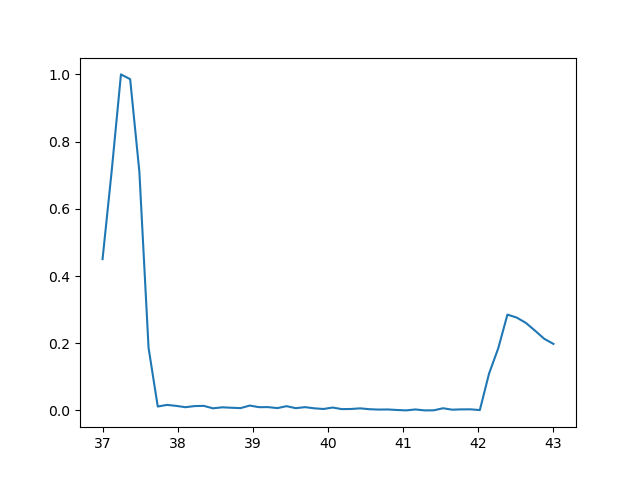

In [5]:
f = plt.figure()
ax = f.gca()
ax.plot(x,y_norm)

In [6]:
peaks, _ = find_peaks(y_norm, height=0.2)
peaks

array([ 5, 47])

In [7]:
for i in range(peaks.shape[0]):
    ax.plot(x[peaks[i]], y_norm[peaks[i]], 'rx')

In [8]:
from scipy.optimize import minimize
# import matplotlib.pyplot as plt

# https://scicomp.stackexchange.com/questions/41795/fitting-a-rectangle-function-to-a-signal-in-python
def bump(x,x1,h0,dh1,dh2,dx1,dx2,a):
    if x <= x1:
        return h0
    x2 = x1 + dx1
    if x > x1 and x <= x2:
        return h0 + (dh1/dx1)*(x - x1)
    x3 = x2 + a
    if x > x2 and x <= x3:
        return h0 + dh1
    x4 = x3 + dx2
    if x > x3 and x <= x4:
        return h0 + dh1 - (dh2/dx2)*(x - x3)
    if x > x4:
        return h0 + dh1 - dh2
    
    
def box(x_array:np.array, x1:float ,h0:float ,dh1:float, dh2:float,dx1:float, dx2:float, a:float):
    
    x_array = np.asarray(x_array)
    y_array:np.array = []
    
    for i in range(x_array.shape[0]):
        yy = bump(x_array[i], x1,h0,dh1,dh2,dx1,dx2,a)
        y_array.append(yy)
        
    y_array = np.asarray(y_array)
    
    return y_array 


# def objective(x):
#     (x1,h0,dh,dx,a) = x
#     error = 0
#     for k in range(len(y)):
#         error += abs(y[k] - bump(t[k],x1,h0,dh,dx,a))
#     return error

# x0 = [0.,0.,1.,0.1,1.1]
# bds = ((-0.5, None),(-0.5, None),(0, None),(0, None),(0.8, None))

In [9]:
x_bump = np.arange(-5, 20, 0.1)
y_bump = box(x_bump, 1,2,3,2,4,7,5)

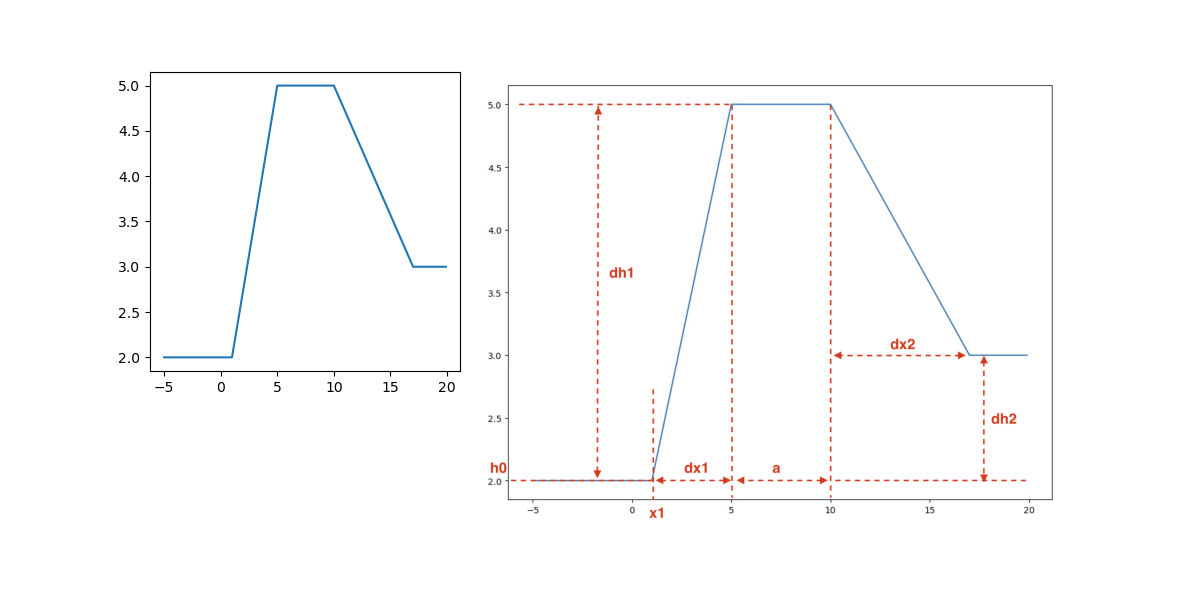

In [10]:
gs = GridSpec(nrows=3, ncols=3, width_ratios=[1.0, 1.0, 1.0])
f1 = plt.figure(figsize=(12, 6),) #constrained_layout=True)

ax1 = f1.add_subplot(gs[0:2,0])
ax1.plot(x_bump, y_bump)

png = 'fitting_box_parameters.png'
img = io.imread(png)
ax1 = f1.add_subplot(gs[:,1:])
ax1.imshow(img)
ax1.set_axis_off()
# plt.axis('off')

f1.subplots_adjust(wspace=0)

In [11]:
from scipy.optimize import curve_fit

# x1=38, h0=0.0, dh1=1.0, dh2=0.4, dx1=0.5, dx2=0.5, a=4.0
initial_guess = [38, 0.0, 1.0, 0.4, 0.5, 0.5, 4.0]
y_norm_r = -(y_norm)
# 3. Perform the curve fitting
popt, pcov = curve_fit(box, x, y_norm_r, p0=initial_guess)

In [12]:
y_curve_fit = box(x, *popt)

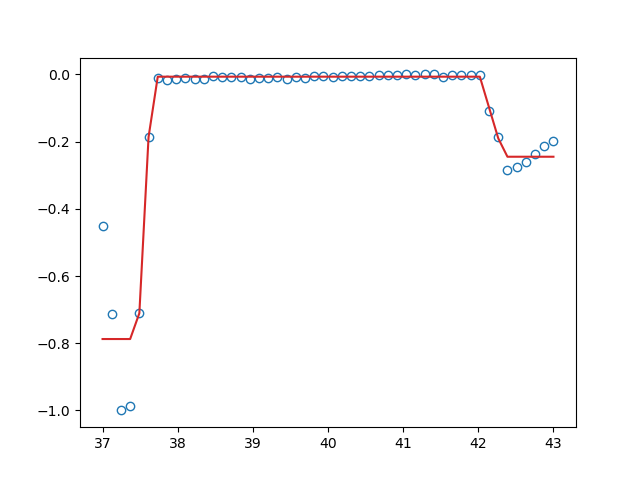

In [13]:
f1 = plt.figure()
ax2 = f1.gca()

ax2.plot(x, y_norm_r, linestyle='none', marker='o', fillstyle='none')
ax2.plot(x, y_curve_fit, color='tab:red')